In [1]:
from sympy import symbols, expand, factor, diff, E, Function, maximum, Derivative, collect, simplify , Matrix, log, apart, Equality
import sympy
def ito_lemma_3D (
G = Function('G')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
    
X_1 = symbols('X_1'),
X_2 = symbols('X_2'),
X_3 = symbols('X_3'),
    
dW_1 = symbols('dW_1'),
dW_2 = symbols('dW_2'),
dW_3 = symbols('dW_3'),   
    
dB_1 = symbols('dB_1'),
dB_2 = symbols('dB_2'),
dB_3 = symbols('dB_3'),  
    
ρ_12 = symbols('ρ_12'),
ρ_13 = symbols('ρ_13'),
ρ_23 = symbols('ρ_23'), 
       
Θ_1 = Function('Θ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_2 = Function('Θ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_3 = Function('Θ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

Ψ_1 = Function('Ψ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_2 = Function('Ψ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_3 = Function('Ψ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

factorize_it = False,
dependent_brownian = True
):


    dt, t = symbols(' dt,  t')

    Θ = Matrix([ 
          [Θ_1] ,
          [Θ_2] ,
          [Θ_3 ] 
    ])

    Ψ = Matrix([ 
          [ Ψ_1,  0      ,  0      ] ,
          [ 0      , Ψ_2 ,  0      ]  ,
          [ 0      ,   0     , Ψ_3 ] 
    ])

    dW = Matrix([ 
          [dW_1] ,
          [dW_2 ],  
          [dW_3 ]
    ])

    dB = Matrix([ 
          [dB_1] ,
          [dB_2 ] ,
          [dB_3 ]  
    ])

    C = Matrix([ 
          [1, ρ_12, ρ_13] ,
          [ρ_12, 1, ρ_23] ,
          [ρ_13 ,ρ_23, 1]
    ])

    L = C.cholesky(hermitian=False)
    Σ = Ψ*L
    
    print("The system of SDE is : ")
    if dependent_brownian :
        dX = Θ * dt + Ψ*dW
        display(dX)
        dX_1 = dX[0]
        dX_2 = dX[1]
        dX_3 = dX[2]
        
        
    else:
        dX = Θ * dt + Σ*dB
        display(dX)
        dX_1 = dX[0]
        dX_2 = dX[1]
        dX_3 = dX[2]



    


    G_t = diff(G, t)

    G_x1 = diff(G, X_1) 
    G_x2 = diff(G, X_2) 
    G_x3 = diff(G, X_3) 

    G_x1_x1 = diff(G_x1, X_1) 
    G_x2_x2 = diff(G_x2, X_2)
    G_x3_x3 = diff(G_x3, X_3)

    G_x1_x2 = diff(G_x1, X_2) 
    G_x1_x3 = diff(G_x1, X_3) 

    G_x2_x1 = diff(G_x2, X_1) 
    G_x2_x3 = diff(G_x2, X_3) 

    G_x3_x1 = diff(G_x3, X_1) 
    G_x3_x2 = diff(G_x3, X_2) 


    dG = G_t*dt + G_x1 * dX_1  + G_x2 * dX_2 +  G_x3 * dX_3  +  1/2* (G_x1_x1 * dX_1 * dX_1 + 
                                                                   G_x2_x2 * dX_2 * dX_2 + 
                                                                   G_x3_x3 * dX_3 * dX_3 + 

                                                                   G_x1_x2 * dX_1 * dX_2 +
                                                                   G_x2_x1 * dX_2 * dX_1 +  

                                                                   G_x1_x3 * dX_1 * dX_3 +
                                                                   G_x3_x1 * dX_3 * dX_1 +

                                                                   G_x2_x3 * dX_2 * dX_3 +
                                                                   G_x3_x2 * dX_3 * dX_2                                                       
                                                                  )  

    dG = (
    expand (dG)
    .subs(dB_1**2, dt)
    .subs(dB_2**2, dt)
    .subs(dB_3**2, dt)
    .subs(dB_1*dt, 0)
    .subs(dB_2*dt, 0)
    .subs(dB_3*dt, 0)
    .subs(dB_1*dB_2, 0)
    .subs(dB_1*dB_3, 0)
    .subs(dB_2*dB_3, 0)
    .subs(dt**2,0)
    .subs(dW_1**2, dt)
    .subs(dW_2**2, dt)
    .subs(dW_3**2, dt)
    .subs(dW_1*dt, 0)
    .subs(dW_2*dt, 0)
    .subs(dW_3*dt, 0)
    .subs(dW_1*dW_2, ρ_12*dt)
    .subs(dW_1*dW_3, ρ_13*dt)
    .subs(dW_2*dW_3, ρ_23*dt)
    .subs(dt**2,0)
    .subs(G, symbols('G'))
    )
    
    return collect(dG , (dt,dB_1,dB_2, dB_3, dW_1,dW_2, dW_3, G ) )  if factorize_it else dG


# Todo

1. Dual curve discounting xCCY spreads

# FX Products

## Spot FX rate $\mathbf{y_f^d}$

1. let's denote $\mathbf{y_d^f}(t)$ the exchange rate that convert  a cash amount denominated in a foreign currency to a domestic currency at time $t$

1. For example if $\mathbf{y_$^€}(t_0) = 0.85$ and we which to exchange USD 100 to euros we have :  $ \$100 \cdot 0.85 \dfrac{€}{\$} = €85$

1. More generally we will use the notation $$y(t) := \mathbf{y_f^d}(t) $$

## FX Forward 

1. One of the most liquid FX products is the so called "outright FX forward". This contract is an obligation for a physical exchange of funds at a future date at an agreed FX rate and there is no upfront payment

1. A way to price an FX forward the replication strategy is used below. whatever option is used the Forward FX rate is the one that makes both options equal in value  <br><br> <kbd>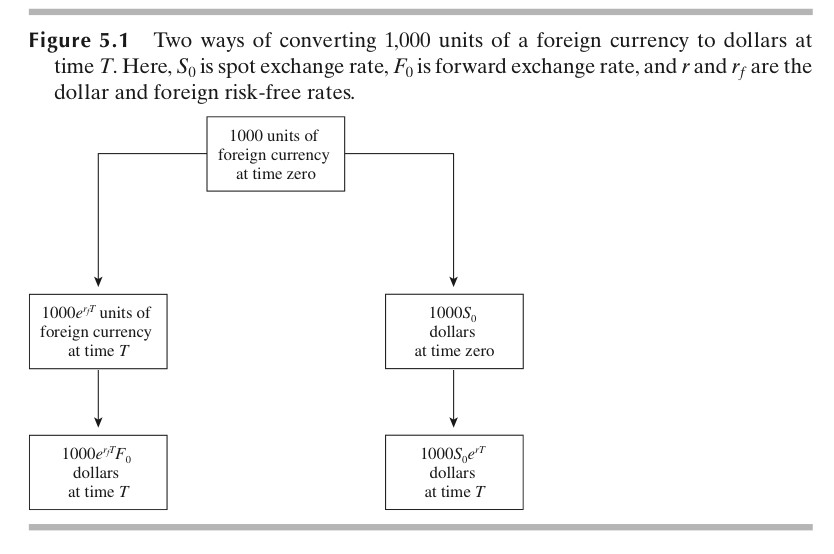</kbd>

1. Another way is to connect to a future FX rate seen from today perspective. For example suppose that we have at a future time $T$ a cashflow $N_f(t)$. We have two possibilities to calculate the value today in domestic currency
    1. We can discount $N_\mathbf{f}(T)$ with the foreign interest rate then convert to domestic curency using today's FX rate. This yields <br><br>$$V^{FX}(t_0) = \mathbb{E}^{\mathbb{Q}^f}\left[  y(t_0) \dfrac{N_\mathbf{f}(T)}{M_\mathbf{f}(T)}  \right] = y(t_0) N_\mathbf{f}(T) P_\mathbf{f}(t_0, T) $$ <br>
    
    1. We can convert $N_\mathbf{f}(T)$ to domestic currency at time $T$ then discount using the domestic interest rate. This yields <br><br>$$V^{FX}(t_0) = \mathbb{E}^{\mathbb{Q}}\left[  \dfrac{y(T) N_\mathbf{f}(T)}{M_\mathbf{d}(T)}  \right] =  N_\mathbf{f}(T) P_\mathbf{d}(t_0, T)\mathbb{E}^{\mathbb{Q}}\left[y(T)   \right] $$<br>

    1. Both ways of calculating the forward should give the same results otherwise arbitrage opportunities occur hence we have the value of the forward FX rate as <br><br>
$$\boxed{y_F(t_0, T) := \mathbb{E}^{\mathbb{Q}}\left[y(T)   \right] = y(t_0) \dfrac{P_\mathbf{f}(t_0, T)}{P_\mathbf{d}(t_0, T)}}$$ <br>

1. The schematic represention of teh above is shown below <br><br>
<kbd>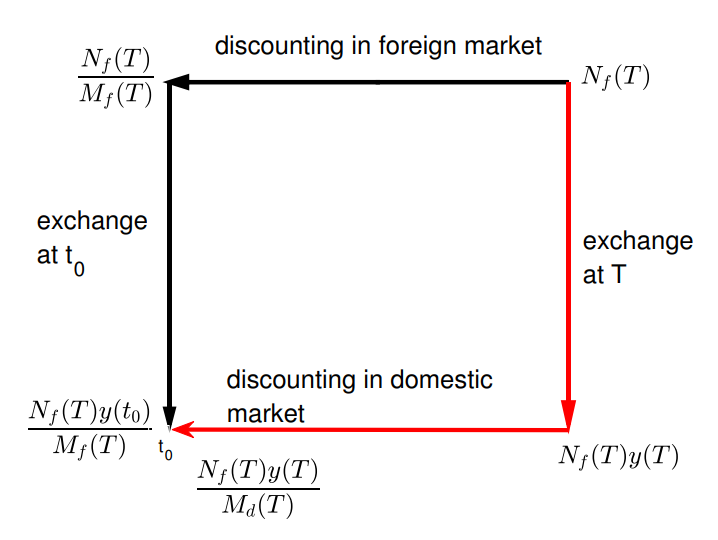</kbd>

1. In other word the forward fx rate $y_F(t_0, T)$ is the expectation of the future exchange rate $y(T)$

## Cross-currency swaps

<kbd>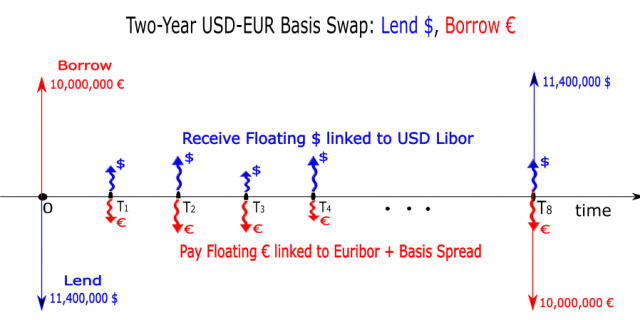

1. a cross currency swap is the typical long-date product. It enable to transform loan in one currency to a loan in a different currency

1. Topically the include and exchange of notionals at the start and end of contract

1. there are various type of xccy swaps ( fixed-fixed, fixed-float, float-float)
    
1. The fixed-fixed xccy swap can be valued simply using the relation <br><br> $$V^{XCCY}= B_D - y(t_0)B_F$$  where 
    * $B_D$ is the value of the bond in domestic currency
    * $B_F$ is the value of the bond in foreign currecny
    

## Pricing of FX Options

### Black-Scholes case

#### Analytical formula

1. Consider the pricing of an European option on FX rate $y(T)$ with payoff $$[y(T) - K]^+ $$

1. we assume that the foreign and domestic interest rates, $r_\mathbf{f}$ and $r_\mathbf{d}$ are constants and the dynamics of the FX rate $y_t$ is GBM then our market is defined as <BR><BR>
$$\begin{align}
dy_t &= \mu y_t dt + \sigma y_t dW^\mathbb{P} \\
dM_\mathbf{d}(t) & = r_\mathbf{d} M_\mathbf{d}(t)  dt \\
dM_\mathbf{f}(t) & = r_\mathbf{f}  M_\mathbf{f}(t)dt \\
\end{align}$$ 
<br><br>

1. Recall that we have the value of the forward FX rate is 
$$y_F(t_0, T) = y(t_0) \dfrac{P_\mathbf{f}(t_0, T)}{P_\mathbf{d}(t_0, T)}$$ <br>
    
1. That means $y_F(T, T) = y(T) $ and $Y_F(T)$ is a martingale under the $\mathbb{T^d}$ foward measure numeraire $P_\mathbf{d}(t_0, T)$

1. the value of the options under $\mathbb{Q^d}$ is 
    
   $$\begin{align}
 V_C^{FX}(t_0) &=  \mathbb{E^{Q^d}}\left[ \dfrac{1}{M_d(T)} (y(T)- K)^+  \right] = \mathbb{E^{Q^d}}\left[ \dfrac{1}{M_d(T)} (y_F(T)- K)^+  \right] \\\\
               &= P_\mathbf{d}(t_0, T) \mathbb{E^{T^d}}\left[ (y_F(T)- K)^+  \right] \\
\end{align}$$ <br><br>
    
1. Because $y_F$ is a martingale under $\mathbb{T^d}$ we can write $$dy_F = \sigma y_F dW^{\mathbb{T^d}}_t$$  <br><br>
    
1. Hence we have $$\boxed{ V_C^{FX}(t_0) =  P_\mathbf{d}(t_0, T) Blk\left(y_F,K,\sigma,T\right)}$$ 


#### FX rate process

1. From previous our market is defined as <BR><BR>
$$\begin{align}
dy_t &= \mu y_t dt + \sigma y_t dW^\mathbb{P} \\
dM_\mathbf{d}(t) & = r_\mathbf{d} M_\mathbf{d}(t)  dt \\
dM_\mathbf{f}(t) & = r_\mathbf{f}  M_\mathbf{f}(t)dt \\
\end{align}$$ 
<br><br>

1. Note that the FX rate is not a tradeable asset so we can't say for example " The FX Process discounted at the money market account is a martingale"
<BR><BR>  
    
1. The tradable assets we have here are: 
    * $M_\mathbf{d}(t)$ : the domestic money market account
    * $M_\mathbf{f}(t)$ : the foreign  money market account
    * $M_\mathbf{f\rightarrow d}(t) = y(t)M_\mathbf{f}(t)$  : the foreing money market account expressed in terms of the domestic currency
<BR><BR>
    
1. Let denote $$\mathscr{X}(t) =  y(t)\frac{M_\mathbf{f}(t)}{M_\mathbf{d}(t)}$$ <br>as the foreign  money market account expressed in term of domestic ccy,  discounted a the domestic market money account. <BR><BR>
    
1. using ito lemma 3D we can find its dynamic as <br><br>
    $$
d\mathscr{X}_t  = (r_\mathbf{f} - r_\mathbf{d} + \mu)\mathscr{X}_t dt + \sigma \mathscr{X}_t dW^{\mathbb{P}}  
$$ 
<BR><BR>    
1. We know that $\mathscr{X}(t)$ is a martingale under $\mathbb{Q^d}$ he have  $$d\mathscr{X}_t  =  \sigma \mathscr{X}_t dW^{\mathbb{Q^d}}$$<BR><BR>
<BR><BR>    

1. By combining the results we have  $$(r_\mathbf{f} - r_\mathbf{d} + \mu)\mathscr{X}_t dt + \sigma \mathscr{X}_t dW^{\mathbb{P}} =  \sigma \mathscr{X}_t dW^{\mathbb{Q^d}}  \\
$$ 
    
1. Hence the change of measure from $\mathbb{P}$ to $\mathbb{Q^d}$ is given by  $$ dW^{\mathbb{Q_d}}_t = \dfrac{r_\mathbf{f} -r_\mathbf{d} + \mu}{\sigma}dt + dW^{\mathbb{P}}_t $$<BR><BR>
    
1. From this we have the dynamic of the FX rate under $\mathbb{Q_d}$ is $$\boxed{dy_t = (r_\mathbf{d} - r_\mathbf{f})y_t dt + \sigma y_t dW^{\mathbb{Q_d}}}$$    <BR><BR>
    


### FX Heston Hullwhite model (FX-HHW)

1. In this model interest rates and volatility are stochastics and are correlated with the FX process

1. In practice we calibrate interest models first then separatly try to calibrate other parameters

1. Here we assume that the foreign and domestic interest rate follow a HW1F model that is : <br><br>
$$\begin{cases}
    dr_{\mathbf{d}} = \lambda \left( \theta_{\mathbf{d}}  - r_{\mathbf{d}} \right) dt + \eta_{\mathbf{d}}  dW^{\mathbb{Q^d}}_{\mathbf{d}}\\ \\
    dr_{\mathbf{f}} = \lambda \left( \theta_{\mathbf{f}}  - r_{\mathbf{f}} \right) dt + \eta_{\mathbf{f}}  dW^{\mathbb{Q^f}}_{\mathbf{f}}
\end{cases}$$

1. The FX-HHW model under $\mathbb{Q}$ is of the following form
$$\begin{cases}
    dy_t = (r_{\mathbf{d}} - r_{\mathbf{f}})y_t dt + \sqrt{v_t}y_tdW_y^{\mathbb{Q}} \\\\
    dv_t = \kappa (\bar{v} - v_t)dt + \gamma\sqrt{v_t}dW_v^{\mathbb{Q}} \\\\
    dr_{\mathbf{d}} = \lambda_{\mathbf{d}} \left( \theta_{\mathbf{d}}  - r_{\mathbf{d}} \right) dt + \eta_{\mathbf{d}}  dW^{\mathbb{Q}}_{\mathbf{d}}\\\\
    dr_{\mathbf{f}} =  \left( \lambda_{\mathbf{f}}(\theta_{\mathbf{f}}  - r_{\mathbf{f}} )\color{darkorange}{- \eta_{\mathbf{f}} \rho_{y,{\mathbf{f}}}\sqrt{v_t}} \right) dt + \eta_{\mathbf{f}}  dW^{\mathbb{Q}}
\end{cases}$$
<br><br>

1. The term in <font color='darkorange'> __orange__ </font> is called the quanto correction terms. This term is present because we need  the quantity below to be martigales under $\mathbb{Q}$ <br><br>
$$\begin{align}
    \varkappa_1(t) &= \dfrac{y(t) M_{\mathbf{f}}(t)    }{M_{\mathbf{d}}(t)} & \text{and} &    &\varkappa_2(t) &= \dfrac{y(t) P_{\mathbf{f}}(t, T)    }{M_{\mathbf{d}}(t)}
\end{align}$$
<br><br>

1. We can confim that the quanto correction work by applying ito lemma and verify the dynamics are martingales under $\mathbb{Q}$. doing this we find <br><br>
$$\begin{align}
    d\varkappa_1(t) &= \sqrt{v_t}\varkappa_1(t)dW_y^{\mathbb{Q}} \\
    d\varkappa_2(t) &= \sqrt{v_t}\varkappa_2(t)dW_y^{\mathbb{Q}} +  \eta_{\mathbf{f}}B_{\mathbf{f}}(t,T)dW_{\mathbf{f}}^{\mathbb{Q}}  \\
\end{align}$$
<br><br>

1. The dynamics of the domestic and foreign are also given as  $\mathbb{Q}$. doing this we find <br><br>
$$\begin{align}
    dP_{\mathbf{d}}(t,T) &=  r_{\mathbf{d}}(t)P_{\mathbf{d}}(t,T)dt + \eta_{\mathbf{d}}B_{\mathbf{d}}(t,T)P_{\mathbf{d}}(t,T)dW_d^{\mathbb{Q}} \\ \\
    dP_{\mathbf{f}}(t,T) &=  \left( r_{\mathbf{f}}(t)    - \eta_{\mathbf{f}} \rho_{y,\mathbf{f}} B_\mathbf{f}(t,T) \sqrt{v_t}      \right) dt + \eta_{\mathbf{f}}B_{\mathbf{f}}(t,T)dW_{\mathbf{f}}^{\mathbb{Q}} \\
\end{align}$$
<br><br>

1. The dynamics of $y_F(t,T)$ under $\mathbb{T^d}$ is given by <br><br>
$$dy_F = \sqrt{v_t}dW_y^{\mathbb{T^d}} - \eta_{\mathbf{d}}B_{\mathbf{d}}(t,T)dW_d^\mathbb{T^d} + \eta_{\mathbf{f}}B_{\mathbf{f}}(t,T)dW_{\mathbf{f}}^\mathbb{T^d}$$

1. Parameter calibration
    * $\rho_{y,d} = corr\left( y_t, r_d \right) \rightarrow $ get from historical data or exotic derivative
    * $\rho_{y,f} = corr\left( y_t, r_f \right) \rightarrow $ read from historical data or exotic derivative
    * $\rho_{y,v} = corr\left( y_t, v_t \right) \rightarrow $ calibrate to instruments

    
